<div style="font-size: 130%; line-height: 1.5;">
In the highly competitive telecom industry, keeping customers satisfied and engaged is essential for long-term success. Interconnect has been facing the challenge of customer churn, where clients decide to cancel their services and move to another provider. Since retaining existing customers is often more cost-effective than attracting new ones, the company wants to better understand which customers may be planning to leave.

To help solve this problem, Interconnect’s marketing team collected customer data, including information about contracts, services, and plans. The goal of this project is to analyze customer behavior patterns and build a machine learning model capable of predicting customer churn. With these predictions, the company can take proactive steps, such as offering personalized promotions or special plans, to improve customer satisfaction and reduce customer loss.
</div>

<div style="font-size: 130%; line-height: 1.5;">
As part of the plan, I will need to perform some EDA and possibly some feature engineering to ensure the dataset is suitable for the model.
</div>

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Model evaluation and selection
from sklearn.model_selection import  train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

In [2]:
# Creating the data frames:

contract = pd.read_csv('/datasets/final_provider/contract.csv')
personal = pd.read_csv('/datasets/final_provider/personal.csv')
internet = pd.read_csv('/datasets/final_provider/internet.csv')
phone = pd.read_csv('/datasets/final_provider/phone.csv')


<div style="font-size: 130%; line-height: 1.5;">
Let's display them:
</div>

In [3]:
contract

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65
...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,1990.5
7039,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7362.9
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,346.45
7041,8361-LTMKD,2019-07-01,2019-11-01 00:00:00,Month-to-month,Yes,Mailed check,74.40,306.6


In [4]:
personal

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes
7039,2234-XADUH,Female,0,Yes,Yes
7040,4801-JZAZL,Female,0,Yes,Yes
7041,8361-LTMKD,Male,1,Yes,No


In [5]:
internet

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...
5512,6840-RESVB,DSL,Yes,No,Yes,Yes,Yes,Yes
5513,2234-XADUH,Fiber optic,No,Yes,Yes,No,Yes,Yes
5514,4801-JZAZL,DSL,Yes,No,No,No,No,No
5515,8361-LTMKD,Fiber optic,No,No,No,No,No,No


In [6]:
phone

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes
...,...,...
6356,2569-WGERO,No
6357,6840-RESVB,Yes
6358,2234-XADUH,Yes
6359,8361-LTMKD,Yes


<div style="font-size: 130%; line-height: 1.5;">
Since all of them have the 'customerID' column, I will be merging them.
</div>

In [7]:
#Starting with contract and personal:
df = contract.merge(personal, on='customerID', how='outer')
df

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,1990.5,Male,0,Yes,Yes
7039,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7362.9,Female,0,Yes,Yes
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,346.45,Female,0,Yes,Yes
7041,8361-LTMKD,2019-07-01,2019-11-01 00:00:00,Month-to-month,Yes,Mailed check,74.40,306.6,Male,1,Yes,No


In [8]:
# Let's merge df and internet
df_1 = df.merge(internet, on='customerID', how='outer')
df_1

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,1990.5,Male,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes
7039,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7362.9,Female,0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,346.45,Female,0,Yes,Yes,DSL,Yes,No,No,No,No,No
7041,8361-LTMKD,2019-07-01,2019-11-01 00:00:00,Month-to-month,Yes,Mailed check,74.40,306.6,Male,1,Yes,No,Fiber optic,No,No,No,No,No,No


In [9]:
# Finnaly, df_1 with phone
df_2 = df_1.merge(phone, on='customerID', how='outer')
df_2

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,No,One year,Yes,Mailed check,84.80,1990.5,Male,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes
7039,2234-XADUH,2014-02-01,No,One year,Yes,Credit card (automatic),103.20,7362.9,Female,0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.60,346.45,Female,0,Yes,Yes,DSL,Yes,No,No,No,No,No,NaN
7041,8361-LTMKD,2019-07-01,2019-11-01 00:00:00,Month-to-month,Yes,Mailed check,74.40,306.6,Male,1,Yes,No,Fiber optic,No,No,No,No,No,No,Yes


<div style="font-size: 130%; line-height: 1.5;">
The data frame with all columns has been created.
I will analyze the columns and the values that are important for the model's performance.
</div>

In [10]:
df_2['Churn'] = df_2['EndDate'].apply(lambda x: 0 if x == 'No' else 1)
df_2 = df_2.drop(['EndDate'], axis = 1)

df_2

,customerID,BeginDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,Churn
0,7590-VHVEG,2020-01-01,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN,0
1,5575-GNVDE,2017-04-01,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No,0
2,3668-QPYBK,2019-10-01,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No,1
3,7795-CFOCW,2016-05-01,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN,0
4,9237-HQITU,2019-09-01,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,One year,Yes,Mailed check,84.80,1990.5,Male,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes,0
7039,2234-XADUH,2014-02-01,One year,Yes,Credit card (automatic),103.20,7362.9,Female,0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,0
7040,4801-JZAZL,2019-03-01,Month-to-month,Yes,Electronic check,29.60,346.45,Female,0,Yes,Yes,DSL,Yes,No,No,No,No,No,NaN,0
7041,8361-LTMKD,2019-07-01,Month-to-month,Yes,Mailed check,74.40,306.6,Male,1,Yes,No,Fiber optic,No,No,No,No,No,No,Yes,1


<div style="font-size: 130%; line-height: 1.5;">
I have created a Churn column, which will tell the model whether the customer has left or not. I also dropped the EndDate column, since it is no longer needed.
</div>

In [11]:
# Converting the BeginDate to a proper datetime column:
df_2['BeginDate'] = pd.to_datetime(df_2['BeginDate'])
df_2['BeginDate']

0      2020-01-01
1      2017-04-01
2      2019-10-01
3      2016-05-01
4      2019-09-01
          ...    
7038   2018-02-01
7039   2014-02-01
7040   2019-03-01
7041   2019-07-01
7042   2014-08-01
Name: BeginDate, Length: 7043, dtype: datetime64[ns]

<div style="font-size: 130%; line-height: 1.5;">
The conversion was successfully completed. Now, let’s display some statistical information before performing the tenure calculation.
</div>

In [12]:
df_2['BeginDate'].describe()

count                    7043
unique                     77
top       2014-02-01 00:00:00
freq                      366
first     2013-10-01 00:00:00
last      2020-02-01 00:00:00
Name: BeginDate, dtype: object

In [13]:
# Calculating Tenure:
reference_date = pd.Timestamp('2020-02-01')
tenure = reference_date - df_2['BeginDate']

tenure

0        31 days
1      1036 days
2       123 days
3      1371 days
4       153 days
          ...   
7038    730 days
7039   2191 days
7040    337 days
7041    215 days
7042   2010 days
Name: BeginDate, Length: 7043, dtype: timedelta64[ns]

In [14]:
tenure = tenure.dt.days
print(tenure.describe())

df_2['tenure'] = tenure
df_2

count    7043.000000
mean     1006.457050
std       736.596428
min         0.000000
25%       306.000000
50%       883.000000
75%      1706.000000
max      2314.000000
Name: BeginDate, dtype: float64


,customerID,BeginDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,...,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,Churn,tenure
0,7590-VHVEG,2020-01-01,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,...,DSL,No,Yes,No,No,No,No,NaN,0,31
1,5575-GNVDE,2017-04-01,One year,No,Mailed check,56.95,1889.5,Male,0,No,...,DSL,Yes,No,Yes,No,No,No,No,0,1036
2,3668-QPYBK,2019-10-01,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,...,DSL,Yes,Yes,No,No,No,No,No,1,123
3,7795-CFOCW,2016-05-01,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,...,DSL,Yes,No,Yes,Yes,No,No,NaN,0,1371
4,9237-HQITU,2019-09-01,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,...,Fiber optic,No,No,No,No,No,No,No,1,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,One year,Yes,Mailed check,84.80,1990.5,Male,0,Yes,...,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes,0,730
7039,2234-XADUH,2014-02-01,One year,Yes,Credit card (automatic),103.20,7362.9,Female,0,Yes,...,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,0,2191
7040,4801-JZAZL,2019-03-01,Month-to-month,Yes,Electronic check,29.60,346.45,Female,0,Yes,...,DSL,Yes,No,No,No,No,No,NaN,0,337
7041,8361-LTMKD,2019-07-01,Month-to-month,Yes,Mailed check,74.40,306.6,Male,1,Yes,...,Fiber optic,No,No,No,No,No,No,Yes,1,215


<div style="font-size: 130%; line-height: 1.5;">
I calculated the tenure and converted the number of days into integers. We can see that most customers stay with the company for a long period of time, averaging about 1,006 days, which is almost 3 years. I will now plot some graphs to make the data easier to visualize.
</div>

In [15]:
df_2.columns

Index(['customerID', 'BeginDate', 'Type', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'MultipleLines', 'Churn', 'tenure'],
      dtype='object')

<div style="font-size: 130%; line-height: 1.5;">
Is the churn behaviour similiar for both male and female genders?
</div>

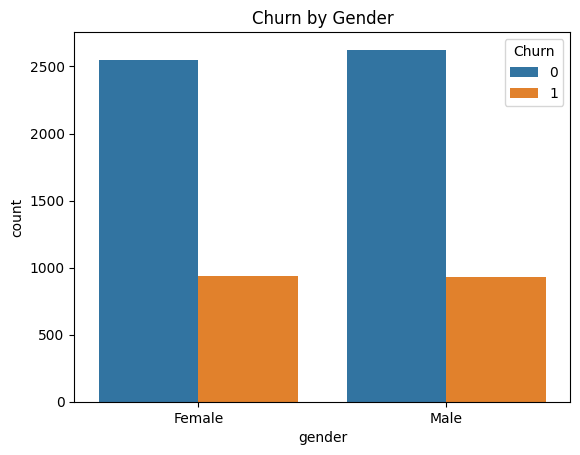

In [16]:
sns.countplot(data=df_2, x='gender', hue='Churn')
plt.title('Churn by Gender')
plt.show()

<div style="font-size: 130%; line-height: 1.5;">
After plotting the graphs, both distributions look very similar. However, I will display some statistical information to determine whether I should keep the gender feature or not.
</div>

In [17]:
df_2.groupby('gender')['Churn'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Female,3488.0,0.269209,0.443612,0.0,0.0,0.0,1.0,1.0
Male,3555.0,0.261603,0.439570,0.0,0.0,0.0,1.0,1.0


<div style="font-size: 130%; line-height: 1.5;">
It is safe to say that they have very similar behavior. In other words, I will drop the gender feature.
</div>

In [18]:
clean_df_2 = df_2.drop('gender', axis =1)
clean_df_2

,customerID,BeginDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,Churn,tenure
0,7590-VHVEG,2020-01-01,Month-to-month,Yes,Electronic check,29.85,29.85,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN,0,31
1,5575-GNVDE,2017-04-01,One year,No,Mailed check,56.95,1889.5,0,No,No,DSL,Yes,No,Yes,No,No,No,No,0,1036
2,3668-QPYBK,2019-10-01,Month-to-month,Yes,Mailed check,53.85,108.15,0,No,No,DSL,Yes,Yes,No,No,No,No,No,1,123
3,7795-CFOCW,2016-05-01,One year,No,Bank transfer (automatic),42.30,1840.75,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN,0,1371
4,9237-HQITU,2019-09-01,Month-to-month,Yes,Electronic check,70.70,151.65,0,No,No,Fiber optic,No,No,No,No,No,No,No,1,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,2018-02-01,One year,Yes,Mailed check,84.80,1990.5,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes,0,730
7039,2234-XADUH,2014-02-01,One year,Yes,Credit card (automatic),103.20,7362.9,0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,0,2191
7040,4801-JZAZL,2019-03-01,Month-to-month,Yes,Electronic check,29.60,346.45,0,Yes,Yes,DSL,Yes,No,No,No,No,No,NaN,0,337
7041,8361-LTMKD,2019-07-01,Month-to-month,Yes,Mailed check,74.40,306.6,1,Yes,No,Fiber optic,No,No,No,No,No,No,Yes,1,215


<div style="font-size: 130%; line-height: 1.5;">
Is the churn behavior similar for both Senior Citizen and not Senior Citizen?
</div>

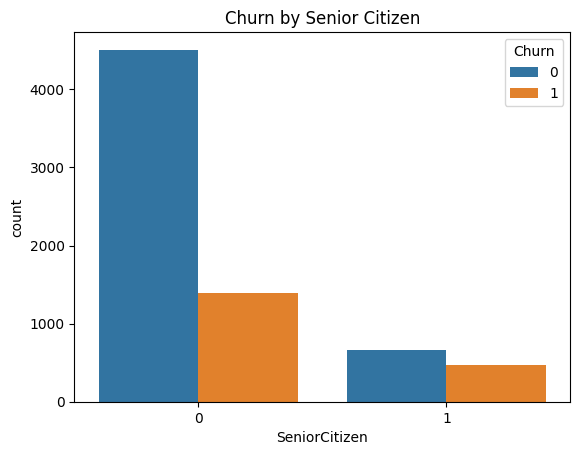

In [19]:
sns.countplot(data=clean_df_2, x='SeniorCitizen', hue='Churn')
plt.title('Churn by Senior Citizen')
plt.show()

<div style="font-size: 130%; line-height: 1.5;">
It seems that non-senior citizen customers have a significantly higher churn rate than senior citizen customers. Let's check the stats to confirm that.
</div>

In [20]:
clean_df_2.groupby('SeniorCitizen')['Churn'].describe()

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,,,,,,,,
0,5901.0,0.236062,0.424697,0.0,0.0,0.0,0.0,1.0
1,1142.0,0.416813,0.493247,0.0,0.0,0.0,1.0,1.0


<div style="font-size: 130%; line-height: 1.5;">
Since there is a big difference in churn rates between senior citizens and non-senior citizens, the SeniorCitizen feature seems useful for predicting churn. Senior citizens are much more likely to leave the company, so this feature can help the model better identify customers who may churn. Because of that, I will be keeping the SeniorCitizen feature.
</div>

<div style="font-size: 130%; line-height: 1.5;">
Is the churn behavior similar for customer with partners and customer without it?
</div>

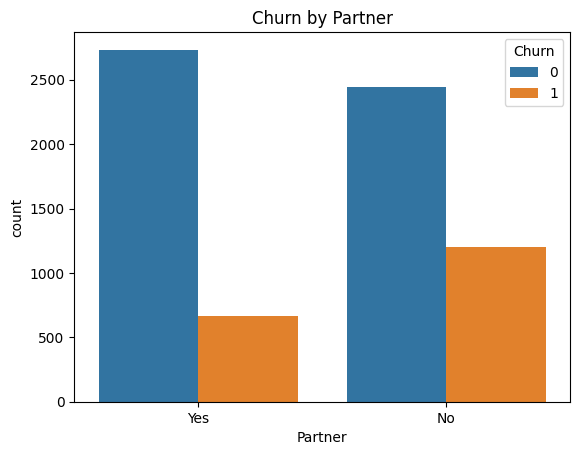

In [21]:
sns.countplot(data=clean_df_2, x='Partner', hue='Churn')
plt.title('Churn by Partner')
plt.show()

<div style="font-size: 130%; line-height: 1.5;">
Just like Senior Citizen, Partner feature seems to have a big difference of churn. Let's display some stats to verify that.
</div>

In [22]:
clean_df_2.groupby('Partner')['Churn'].describe()

,count,mean,std,min,25%,50%,75%,max
Partner,,,,,,,,
No,3641.0,0.329580,0.470125,0.0,0.0,0.0,1.0,1.0
Yes,3402.0,0.196649,0.397523,0.0,0.0,0.0,0.0,1.0


<div style="font-size: 130%; line-height: 1.5;">
Similar to what we saw with Senior Citizen, happened to Partner. Because of that, I will also keep it.
</div>

<div style="font-size: 130%; line-height: 1.5;">
Does TotalCharges carry unique information that MonthlyCharges and tenure together don't fully capture?
</div>

In [23]:
clean_df_2[['MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']].corr()

,MonthlyCharges,tenure,Churn
MonthlyCharges,1.000000,0.260860,0.193356
tenure,0.260860,1.000000,-0.311715
Churn,0.193356,-0.311715,1.000000


In [24]:
clean_df_2[['MonthlyCharges', 'TotalCharges', 'tenure']].dtypes

MonthlyCharges    float64
TotalCharges       object
tenure              int64
dtype: object

<div style="font-size: 130%; line-height: 1.5;">
I will change the data type of the Total Charges features, so I can see the correlation between them.
</div>

In [25]:
clean_df_2['TotalCharges'] = pd.to_numeric(clean_df_2['TotalCharges'], errors='coerce')
clean_df_2['TotalCharges'].dtypes

dtype('float64')

<div style="font-size: 130%; line-height: 1.5;">
Applying the correlation again:
</div>

In [26]:
clean_df_2[['MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']].corr()

,MonthlyCharges,TotalCharges,tenure,Churn
MonthlyCharges,1.000000,0.651065,0.260860,0.193356
TotalCharges,0.651065,1.000000,0.829135,-0.199484
tenure,0.260860,0.829135,1.000000,-0.311715
Churn,0.193356,-0.199484,-0.311715,1.000000


<div style="font-size: 130%; line-height: 1.5;">
I will be dropping the TotalCharges feature because it does not provide much new information to the model. This variable is essentially a combination of MonthlyCharges and customer tenure, since it represents the total amount a customer has paid over time. Because of that, the model can already capture this information through those two existing features. Keeping TotalCharges could introduce redundancy and unnecessary correlation between variables, while removing it simplifies the dataset without significantly affecting the model’s performance.
</div>

<div style="font-size: 130%; line-height: 1.5;">
I will also drop the customerID and BeginDate features. The first one only serves to identify customers and does not provide useful information for predicting churn. As for BeginDate, I have already created the tenure feature, which captures the same information in a more useful way for the model.
</div>

In [27]:
final_df_2 = clean_df_2.drop(['customerID', 'BeginDate', 'TotalCharges'], axis=1)
final_df_2

,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,Churn,tenure
0,Month-to-month,Yes,Electronic check,29.85,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN,0,31
1,One year,No,Mailed check,56.95,0,No,No,DSL,Yes,No,Yes,No,No,No,No,0,1036
2,Month-to-month,Yes,Mailed check,53.85,0,No,No,DSL,Yes,Yes,No,No,No,No,No,1,123
3,One year,No,Bank transfer (automatic),42.30,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN,0,1371
4,Month-to-month,Yes,Electronic check,70.70,0,No,No,Fiber optic,No,No,No,No,No,No,No,1,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,One year,Yes,Mailed check,84.80,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes,0,730
7039,One year,Yes,Credit card (automatic),103.20,0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,0,2191
7040,Month-to-month,Yes,Electronic check,29.60,0,Yes,Yes,DSL,Yes,No,No,No,No,No,NaN,0,337
7041,Month-to-month,Yes,Mailed check,74.40,1,Yes,No,Fiber optic,No,No,No,No,No,No,Yes,1,215


<div style="font-size: 130%; line-height: 1.5;">
If there is more features not important to the model, I will see as I analyze the model's performance.
</div>

<div style="font-size: 130%; line-height: 1.5;">
Before proceed to the last part of the work plan, I will check if there is any duplicates and missing values on our df. Also, I need to encode the categorical columns in the dataset.
</div>

In [28]:
final_df_2.isnull().sum()

Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
Churn                  0
tenure                 0
dtype: int64

<div style="font-size: 130%; line-height: 1.5;">
The missing values were created during the merging process. Instead of dropping them, I will fill those missing values with 'No service'.
</div>

In [29]:
final_df_2 = final_df_2.fillna('No service')
final_df_2.isnull().sum()

Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
Churn               0
tenure              0
dtype: int64

<div style="font-size: 130%; line-height: 1.5;">
Lastly, Let's check for duplicates
</div>

In [30]:
final_df_2.duplicated().sum()

39

<div style="font-size: 130%; line-height: 1.5;">
I will drop the duplicate rows to avoid having customers with the same data, especially since there are only 39 duplicate values.
</div>

In [31]:
final_data = final_df_2.drop_duplicates()
final_data

,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,Churn,tenure
0,Month-to-month,Yes,Electronic check,29.85,0,Yes,No,DSL,No,Yes,No,No,No,No,No service,0,31
1,One year,No,Mailed check,56.95,0,No,No,DSL,Yes,No,Yes,No,No,No,No,0,1036
2,Month-to-month,Yes,Mailed check,53.85,0,No,No,DSL,Yes,Yes,No,No,No,No,No,1,123
3,One year,No,Bank transfer (automatic),42.30,0,No,No,DSL,Yes,No,Yes,Yes,No,No,No service,0,1371
4,Month-to-month,Yes,Electronic check,70.70,0,No,No,Fiber optic,No,No,No,No,No,No,No,1,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,One year,Yes,Mailed check,84.80,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Yes,0,730
7039,One year,Yes,Credit card (automatic),103.20,0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,0,2191
7040,Month-to-month,Yes,Electronic check,29.60,0,Yes,Yes,DSL,Yes,No,No,No,No,No,No service,0,337
7041,Month-to-month,Yes,Mailed check,74.40,1,Yes,No,Fiber optic,No,No,No,No,No,No,Yes,1,215


<div style="font-size: 130%; line-height: 1.5;">
Lastly, let's encode the categorical features
</div>

In [32]:
final_data = final_df_2.drop_duplicates().copy()

categorical_cols = [
    'Type', 'PaymentMethod', 'InternetService', 'PaperlessBilling',
    'Partner', 'Dependents', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'MultipleLines'
]

final_data = pd.get_dummies(
    final_data,
    columns=categorical_cols,
    drop_first=True 
)

final_data

,MonthlyCharges,SeniorCitizen,Churn,tenure,Type_One year,Type_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,...,DeviceProtection_No service,DeviceProtection_Yes,TechSupport_No service,TechSupport_Yes,StreamingTV_No service,StreamingTV_Yes,StreamingMovies_No service,StreamingMovies_Yes,MultipleLines_No service,MultipleLines_Yes
0,29.85,0,0,31,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
1,56.95,0,0,1036,1,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,0
2,53.85,0,1,123,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,42.30,0,0,1371,1,0,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
4,70.70,0,1,153,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,84.80,0,0,730,1,0,0,0,1,0,...,0,1,0,1,0,1,0,1,0,1
7039,103.20,0,0,2191,1,0,1,0,0,1,...,0,1,0,0,0,1,0,1,0,1
7040,29.60,0,0,337,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
7041,74.40,1,1,215,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,1


<div style="font-size: 130%; line-height: 1.5;">
Encoding has been performed using One-Hot Encoding, as the categorical features do not have any meaningful order. This approach is preferred over label encoding because some machine learning models, such as Logistic Regression, can be sensitive to numerical ordering introduced by label encoding. Let's proceed to the final step of the work plan.
</div>

<div style="font-size: 140%; line-height: 1.5;">
List of clarifying questions:
</div>

<div style="font-size: 130%; line-height: 1.5;">
Is the churn behaviour similiar for both male and female genders?
</div>

<div style="font-size: 130%; line-height: 1.5;">
Is the churn behavior similar for both Senior Citizen and not Senior Citizen?
</div>

<div style="font-size: 130%; line-height: 1.5;">
Is the churn behavior similar for customer with partners and customer without it?
</div>

<div style="font-size: 130%; line-height: 1.5;">
All questions were answered during my EDA step.
</div>

<div style="font-size: 180%; line-height: 1.5;">
Work Plan:
</div>

<div style="font-size: 130%; line-height: 1.5;">

</div>

<div style="font-size: 130%; line-height: 1.5;">
# Step 1: Data Preparation

I will load the data and merge all datasets into a single DataFrame. I will also perform feature engineering by creating two important features: Churn and Tenure. After that, I will conduct exploratory data analysis (EDA) to determine which features are not important to the model's performance. Finally, I will check for missing values and duplicates, and convert categorical variables into numerical values.
</div>

<div style="font-size: 130%; line-height: 1.5;">
# Step 2: Preprocessing

I will separate the features (X) from the target variable (Y), where the target variable will be the Churn feature. After that, I will split the data into training and testing sets. I will also check whether the target classes are imbalanced and apply techniques to handle class imbalance if necessary. Since some machine learning models are sensitive to feature scale, I will scale the numerical features before training the models.
</div>

<div style="font-size: 130%; line-height: 1.5;">
# Step 3: Modeling and evaluation

I will train and compare different machine learning models to determine which one performs best. I will start with a baseline model using Logistic Regression, then move to tree-based models such as Decision Tree and Random Forest, and finally use boosting models such as LightGBM and CatBoost. Lastly, I will evaluate all models using the AUC-ROC score and select the best-performing model.
</div>

<div style="font-size: 130%; line-height: 1.5;">
#Step 4: Analyze Results and Draw Conclusions 
    
After selecting the best-performing model, I will analyze its performance and identify the most important factors related to customer churn. Finally, I will summarize the results and provide conclusions about how the model can help predict customer churn more effectively.
</div>

<div style="font-size: 130%; line-height: 1.5;">
As stated in the work plan, let’s start with Step 2: preprocessing.
</div>

In [33]:
# Defining variables: X-features, Y-target
X = final_data.drop(['Churn'], axis=1)
Y = final_data['Churn']

# Let's create one test split in the begining:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, stratify=Y, test_size=0.2, random_state=12345
)

print(f"Training+Validation set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print("Test set is now separated until final evaluation!")

Training+Validation set size: 5603
Test set size: 1401
Test set is now separated until final evaluation!


<div style="font-size: 130%; line-height: 1.5;">
Variables were defined and a train-test split was created. Also, stratify=Y was used to preserve the original class distribution in both the training and validation sets, ensuring that model evaluation is not biased due to class imbalance. Let’s now check for class imbalance.
</div>

In [34]:
Y.value_counts(normalize=True) * 100

0    73.386636
1    26.613364
Name: Churn, dtype: float64

<div style="font-size: 130%; line-height: 1.5;">
As we can see, there is a class imbalance. About 73% of the customers stayed with the company, and only 27% left. To address this issue, I will use `class_weight='balanced'` in the models that support this parameter. This strategy helps the model pay more attention to the minority class and reduces bias toward the majority class during training.
</div>

<div style="font-size: 130%; line-height: 1.5;">
The last step in Step 2 is scaling the numerical features before training the models. However, applying scaling at this stage could introduce data leakage if it is done before properly splitting the data. To avoid this, the scaling process is included inside the model evaluation function, where it is fitted only on the training subset and then applied to the validation set. The test set is scaled separately before the final evaluation, using the parameters learned from the training data only. The only features that require scaling are MonthlyCharges and tenure, as they have a wider range of values compared to the other features.
</div>

<div style="font-size: 130%; line-height: 1.5;">
Scaling was completed successfully. Let’s move on to Step 3: Modeling and Evaluation. 
</div>

<div style="font-size: 130%; line-height: 1.5;">
Let's build a function that will help us create the models
</div>

In [35]:
# Creating a function:
def model_evaluation(model, X, Y):

    X_train, X_valid, Y_train, Y_valid = train_test_split(
        X, Y, stratify=Y, test_size=0.2, random_state=12345
    )
    
    # Scaling only the training and validation set
    cols_to_scale = ['MonthlyCharges', 'tenure']

    scaler = StandardScaler()

    X_train = X_train.copy()
    X_valid = X_valid.copy()

    X_train.loc[:, cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
    X_valid.loc[:, cols_to_scale] = scaler.transform(X_valid[cols_to_scale])

    #Training the model
    model.fit(X_train, Y_train)

    #Validation Predictions:
    valid_predictions = model.predict(X_valid)

    # Probabilities for ROC-AUC:
    valid_probabilities = model.predict_proba(X_valid)[:, 1]

    # Metrics:
    roc_auc = roc_auc_score(Y_valid, valid_probabilities)
    accuracy = accuracy_score(Y_valid, valid_predictions)

    return roc_auc, accuracy

In [36]:
models = {'logistic': LogisticRegression(class_weight='balanced'),
         'decision': DecisionTreeClassifier(class_weight='balanced'),
         'forest': RandomForestClassifier(class_weight='balanced'),
         'lgbm': LGBMClassifier(class_weight='balanced'),
          'cat_boost': CatBoostClassifier(verbose=0, auto_class_weights='Balanced')
}

<div style="font-size: 130%; line-height: 1.5;">
To handle class imbalance, I applied built-in class weighting methods: class_weight='balanced' for scikit-learn models and auto_class_weights='Balanced' for CatBoost. These approaches automatically adjust for unequal class distributions and improve the model’s focus on the minority class.
</div>

In [37]:
#Let's create a for loop to display roc_auc and accuracy:
results = []
for name, model in models.items():
    roc_auc, accuracy = model_evaluation(model, X_train, Y_train)
    results.append({'model_name': name,
                   'roc_auc': roc_auc,
                   'accuracy': accuracy})


In [38]:
print("After calculating the roc_auc and accuracy, we have:\n")
results

After calculating the roc_auc and accuracy, we have:



[{'model_name': 'logistic',
  'roc_auc': 0.8402839505166072,
  'accuracy': 0.743978590544157},
 {'model_name': 'decision',
  'roc_auc': 0.6699788790396896,
  'accuracy': 0.7448706512042819},
 {'model_name': 'forest',
  'roc_auc': 0.8182129547326444,
  'accuracy': 0.784121320249777},
 {'model_name': 'lgbm',
  'roc_auc': 0.8452604238870721,
  'accuracy': 0.7689562890276539},
 {'model_name': 'cat_boost',
  'roc_auc': 0.8521960905836399,
  'accuracy': 0.775200713648528}]

<div style="font-size: 130%; line-height: 1.5;">
The initial results were encouraging, with several models achieving strong AUC-ROC scores. Next, I will train each model individually using different hyperparameter settings to determine the best-performing model. Once selected, the final model will be evaluated on the test split to assess its performance on unseen data.
</div>

<div style="font-size: 130%; line-height: 1.5;">
Based on the initial results, I selected the best-performing models (CatBoost, LightGBM, and Logistic Regression) for hyperparameter tuning. Random Forest and Decision Tree were excluded to focus on the most promising approaches. The final model will be chosen based on ROC-AUC on the validation set and then evaluated on the test set.
</div>

In [39]:
# Starting with CatBoost:
cat_boost_models = {
    'cat_boost_1': CatBoostClassifier(iterations=100, random_seed=12345, verbose=0, auto_class_weights='Balanced'),
    'cat_boost_2': CatBoostClassifier(iterations=200, random_seed=12345, verbose=0, auto_class_weights='Balanced'),
    'cat_boost_3': CatBoostClassifier(iterations=300, random_seed=12345, verbose=0, auto_class_weights='Balanced')
}

# Testing with roc_auc and acuracy metric:
cat_boost_results = []

for name, model in cat_boost_models.items():
    roc_auc, accuracy = model_evaluation(model, X_train, Y_train)
    cat_boost_results.append({'model_name': name,
                   'roc_auc': roc_auc,
                   'accuracy': accuracy})


print("This is the evaluation utilizing the CatBoost libraries:")
cat_boost_results

This is the evaluation utilizing the CatBoost libraries:


[{'model_name': 'cat_boost_1',
  'roc_auc': 0.8553948151712102,
  'accuracy': 0.7716324710080286},
 {'model_name': 'cat_boost_2',
  'roc_auc': 0.8535722149281968,
  'accuracy': 0.7778768956289027},
 {'model_name': 'cat_boost_3',
  'roc_auc': 0.8534193122232462,
  'accuracy': 0.775200713648528}]

<div style="font-size: 130%; line-height: 1.5;">
The CatBoost models achieved strong results, and the best-performing model was CatBoost_1. Let's move on to LightGBM models.
</div>

In [40]:
# LightGBM:
lgbm_models = {'lgbm_1': LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=7, class_weight='balanced'),
    'lgbm_2': LGBMClassifier(n_estimators=100, learning_rate=0.05, max_depth=10, class_weight='balanced'),
    'lgbm_3': LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=12, class_weight='balanced')}


# Testing them:
lgbm_results = []
for name, model in lgbm_models.items():
    roc_auc, accuracy = model_evaluation(model, X_train, Y_train)
    lgbm_results.append({'model_name': name,
                   'roc_auc': roc_auc,
                   'accuracy': accuracy})
    
print("This is the evaluation utilizing the LGBM libraries:")
lgbm_results

This is the evaluation utilizing the LGBM libraries:


[{'model_name': 'lgbm_1',
  'roc_auc': 0.852088039338808,
  'accuracy': 0.7823371989295272},
 {'model_name': 'lgbm_2',
  'roc_auc': 0.8576088463388976,
  'accuracy': 0.7743086529884032},
 {'model_name': 'lgbm_3',
  'roc_auc': 0.8428078644996615,
  'accuracy': 0.7725245316681534}]

<div style="font-size: 130%; line-height: 1.5;">
Like CatBoost, the LightGBM models achieved strong results. The best model, LGBM_2, achieved a ROC-AUC of approximately 0.86, which is a very good score. This score is slightly higher than the best CatBoost model, which also achieved a ROC-AUC of approximately 0.86. However, the difference is very small, so both models have equivalent performance.

Finally, let's analyze the Logistic Regression models.
</div>

In [41]:
# LogisticRegression:
logistic_models = {
    'logistic_1': LogisticRegression(C=0.01, max_iter=1000, class_weight='balanced'),
    'logistic_2': LogisticRegression(C=1, max_iter=1000, class_weight='balanced'),
    'logistic_3': LogisticRegression(C=100, max_iter=1000, class_weight='balanced')
}

# Testing them:
logistic_results = []
for name, model in logistic_models.items():
    roc_auc, accuracy = model_evaluation(model, X_train, Y_train)
    logistic_results.append({'model_name': name,
                   'roc_auc': roc_auc,
                   'accuracy': accuracy})
    
print("This is the evaluation utilizing the Logistic Regression:")
logistic_results

This is the evaluation utilizing the Logistic Regression:


[{'model_name': 'logistic_1',
  'roc_auc': 0.830775440971401,
  'accuracy': 0.7448706512042819},
 {'model_name': 'logistic_2',
  'roc_auc': 0.8402839505166072,
  'accuracy': 0.743978590544157},
 {'model_name': 'logistic_3',
  'roc_auc': 0.8406998458740735,
  'accuracy': 0.7448706512042819}]

<div style="font-size: 130%; line-height: 1.5;">
For Logistic Regression, I tuned the regularization strength (C) to evaluate the effect of different levels of regularization on model performance. Although the models achieved good results, they did not outperform CatBoost and LightGBM. Therefore, only the best CatBoost and LightGBM models were selected for final evaluation on the test set.
</div>

<div style="font-size: 130%; line-height: 1.5;">
Before I proceed to final evaluation, I will be transforming the test set.
</div>

In [42]:
scaler = StandardScaler()

cols_to_scale = ['MonthlyCharges', 'tenure']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(
    X_train_scaled[cols_to_scale]
)

X_test_scaled[cols_to_scale] = scaler.transform(
    X_test_scaled[cols_to_scale]
)

<div style="font-size: 130%; line-height: 1.5;">
Before training the final CatBoost and LightGBM models, a new StandardScaler was fitted on the full training set and applied to the test set. This ensured that all available training data contributed to the scaling parameters while preventing data leakage, since the test set was only transformed and not used to fit the scaler.
</div>

<div style="font-size: 130%; line-height: 1.5;">
Let's move on to final evaluation on the test set.
</div>

In [43]:
# Defining final models:
cat_final = cat_boost_models['cat_boost_1']
cat_final.fit(X_train, Y_train)

lgbm_final = lgbm_models['lgbm_2']
lgbm_final.fit(X_train, Y_train)

# Let's do the final prediction and final probability calculation:
cat_pred  = cat_final.predict(X_test)
cat_proba = cat_final.predict_proba(X_test)[:, 1]

lgbm_pred = lgbm_final.predict(X_test)
lgbm_proba = lgbm_final.predict_proba(X_test)[:, 1]


print("CatBoost ROC-AUC:", roc_auc_score(Y_test, cat_proba))
print("CatBoost Accuracy:", accuracy_score(Y_test, cat_pred))

print("LightGBM ROC-AUC:", roc_auc_score(Y_test, lgbm_proba))
print("LightGBM Accuracy:", accuracy_score(Y_test, lgbm_pred))

CatBoost ROC-AUC: 0.8482164279529736
CatBoost Accuracy: 0.7694503925767309
LightGBM ROC-AUC: 0.8502780066971971
LightGBM Accuracy: 0.7594575303354747


<div style="font-size: 130%; line-height: 1.5;">
"The models achieved very similar results and both performed well. LightGBM achieved the highest ROC-AUC score (0.8503), while CatBoost obtained the highest accuracy (0.7695). Since the performance difference was minimal, either model would be a strong choice.
</div>

## Conclusion

<div style="font-size: 165%; line-height: 1.5;">
This project focused on developing a machine learning solution to identify customers at risk of churn for Interconnect. By analyzing historical customer data, predictive models were built to help the company proactively retain customers through targeted marketing and retention strategies.

Among the evaluated models, CatBoost and LightGBM achieved very similar performance. On the final test set, LightGBM obtained the highest ROC-AUC score (0.8503), while CatBoost achieved slightly higher accuracy (0.7695).

Based on the primary evaluation metric, ROC-AUC, LightGBM is recommended as the final model, as it demonstrated the best ability to distinguish between customers who are likely to churn and those who are not.

From a business perspective, implementing this model can help Interconnect identify at-risk customers more effectively, improve retention efforts, and support long-term revenue stability through data-driven decision-making.
</div>

## Solution Report

## What steps of the plan were performed and what steps were skipped (explain why)?

<div style="font-size: 130%; line-height: 1.5;">
All planned steps were successfully completed during the project. The workflow began with data preprocessing, which included data cleaning, handling missing values, feature engineering, and preparation of the datasets for modeling. Exploratory data analysis was then performed to better understand the data, identify patterns, and evaluate relationships between features and the target variable.

Next, multiple machine learning models were developed, trained, and evaluated using appropriate performance metrics. Hyperparameter tuning was conducted to optimize model performance and ensure reliable predictions. After comparing the results, the best-performing model was selected based on its predictive performance.

Finally, the selected model was analyzed to identify the most important factors influencing customer churn, and conclusions were drawn regarding its effectiveness in predicting customer behavior. No planned steps were skipped, as all stages of the project were completed according to the original plan.
</div>

## What difficulties did you encounter and how did you manage to solve them?

<div style="font-size: 130%; line-height: 1.5;">
One of the main difficulties I encountered was determining which features were the most relevant for the model's predictions. To address this challenge, I performed exploratory data analysis (EDA), analyzed feature importance, and created statistical visualizations to better understand the relationship between the features and customer churn. This helped me identify which variables contributed the most to the model's performance.

Another challenge was selecting the most appropriate method for encoding categorical features. Initially, I considered using Label Encoding, but after evaluating the characteristics of the dataset, I determined that One-Hot Encoding was a better choice because it avoids introducing artificial ordinal relationships between categories. After applying the encoding method, I verified that the training, validation, and test sets were processed consistently, ensuring reliable model performance.
</div>

## What were some of the key steps to solving the task?

<div style="font-size: 130%; line-height: 1.5;">
Some of the key steps in solving this task were data preprocessing, exploratory data analysis, feature engineering, model development, and model evaluation. Data preprocessing was essential to clean the data, handle missing values, and prepare the features for machine learning algorithms. Exploratory data analysis helped identify patterns, trends, and relationships between customer characteristics and churn behavior.

Another important step was selecting and transforming the features appropriately, including the use of One-Hot Encoding for categorical variables. Multiple machine learning models were then trained and compared to determine which approach produced the best predictive performance. Finally, model evaluation using metrics such as ROC-AUC allowed for an objective comparison of the models and helped identify the most effective solution for predicting customer churn.
</div>

## What is your final model and what quality score does it have?

<div style="font-size: 130%; line-height: 1.5;">
The final model selected for this project was LightGBM. Although both models performed well, LightGBM achieved the highest ROC-AUC score of 0.8503 on the test set, slightly outperforming CatBoost, which achieved a ROC-AUC score of 0.8482. Since ROC-AUC was the primary evaluation metric for this classification task, LightGBM was chosen as the final model.

The final LightGBM model achieved a ROC-AUC score of 0.8503 and an accuracy score of 0.7595, demonstrating a strong ability to distinguish between customers who are likely to churn and those who are likely to remain with the company.
</div>

## Business Impact

<div style="font-size: 130%; line-height: 1.5;">
The final LightGBM model can be used to identify customers who are most likely to churn, allowing Interconnect to focus retention efforts on high-risk customers. By targeting these customers with personalized offers and support, the company can improve customer retention and reduce potential revenue loss.
</div>